# Define settings

In [13]:
exec(open('/Users/ricard/gastrulation_multiome_10x/settings.py').read())

# Load data

In [14]:
adata = load_adata("/Users/ricard/data/gastrulation_multiome_10x/processed/rna/anndata.h5ad")

In [15]:
# adata = adata[(adata.obs["pass_QC"]==True) & (adata.obs["celltype.mapped"]!="nan"),:]
sum(adata.obs["pass_QC"]==False)

0

NameError: name 'metadata' is not defined

In [16]:
from IPython.display import display
display(adata.obs.head())

,sample,barcode,nFeature_RNA,nCount_RNA,percent.mt,pass_QC,log_nCount_RNA,celltype.mapped,celltype.score,closest.cell,cxds_score,cxds_call,bcds_score,bcds_call,hybrid_score,hybrid_call
E7.5_rep1_AAACAGCCAAACCCTA-1,E7.5_rep1,AAACAGCCAAACCCTA-1,8588,62088,19.757441,True,15.922027,Visceral_endoderm,0.64,cell_79220,92823.552480,True,0.951041,True,1.963242,True
E7.5_rep1_AAACAGCCAAACTCAT-1,E7.5_rep1,AAACAGCCAAACTCAT-1,2929,7538,16.105068,True,12.879966,Def._endoderm,0.36,cell_44527,14282.212085,False,0.032984,False,0.185994,False
E7.5_rep1_AAACAGCCACAACCTA-1,E7.5_rep1,AAACAGCCACAACCTA-1,4125,12134,20.092303,True,13.566768,ExE_ectoderm,1.00,cell_8101,1576.774008,False,0.012279,False,0.028113,False
E7.5_rep1_AAACAGCCAGGAACTG-1,E7.5_rep1,AAACAGCCAGGAACTG-1,1636,3268,22.552020,True,11.674192,Def._endoderm,0.80,cell_82546,4227.947882,False,0.011167,False,0.055548,False
E7.5_rep1_AAACAGCCATCCTGAA-1,E7.5_rep1,AAACAGCCATCCTGAA-1,2676,6033,21.631029,True,12.558660,Nascent_mesoderm,0.88,cell_87810,9054.615326,False,0.005723,False,0.102026,False


In [17]:
sc.pp.recipe_zheng17(adata)

/Users/ricard/anaconda3/envs/base_new/lib/python3.6/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if not is_categorical(df_full[k]):
/Users/ricard/anaconda3/envs/base_new/lib/python3.6/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if not is_categorical(df_full[k]):


In [18]:
sc.tl.pca(adata, svd_solver='arpack')

In [19]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)

In [20]:
sc.tl.umap(adata, min_dist=0.5)

In [21]:
adata.obsm["X_umap"].shape

(30015, 2)

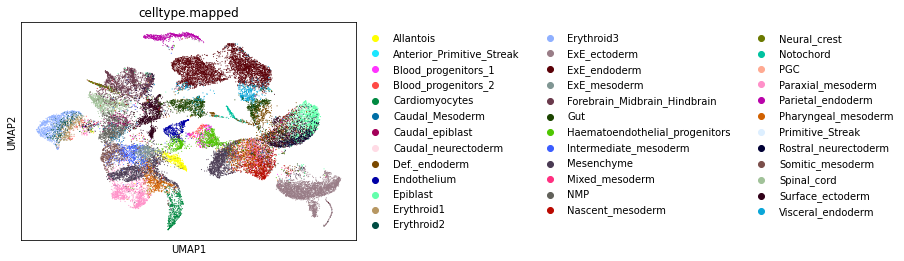

In [22]:
sc.pl.umap(adata, color="celltype.mapped", legend_loc="right margin")

In [23]:
colPalette_celltypes = [opts["celltype.colors"][i.replace(" ","_")] for i in sorted(np.unique(adata.obs['celltype.mapped']))]
adata.uns['celltype.mapped_colors'] = colPalette_celltypes

KeyError: 'celltype.colors'

In [ ]:
colPalette_stages = [opts["stages_colors"][i.replace(" ","_")] for i in sorted(np.unique(adata.obs['stage']))]
adata.uns['stage_colors'] = colPalette_stages

In [ ]:
sc.pl.umap(adata, color=['stage'], legend_loc='right margin')

In [ ]:
sc.pp.recipe_zheng17(adata)